In [1]:
import composable.records as rec

In [9]:
# Standard imports
import polars as pl
import polars.selectors as cs
import seaborn as sns
import numpy as np

# Preprocessing stuff
from sklearn.preprocessing import LabelEncoder

# Model selection stuff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Classic classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
# Metrics to use on the test set
# metric(y_test, y_predict)
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Homework 3

## Problem 1: 
1.	Load the data and use pair plots to visualize the relationships.  Identify a few features that look like promising discriminators. (breast data)
2.	Split the data into training and test sets.
3.	Use the training data to find the best classifier and report on the winning model.
4.	Evaluate the performance of the winning model using the test set.


In [75]:
(breast := pl.read_csv("data/BreastDiag.csv"))

Diagnosis,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,ConcavePts,Symmetry,FracDim,serad,setex,seperi,searea,sesmoo,secomp,seconc,seconpts,sesym,sefd,wrad,wtex,wperi,warea,wsmoo,wcomp,wconc,wconpts,wsym,wfd
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""M""",17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
"""M""",20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902
"""M""",19.69,21.25,130.0,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.243,0.3613,0.08758
"""M""",11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173
"""M""",20.29,14.34,135.1,1297.0,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575.0,0.1374,0.205,0.4,0.1625,0.2364,0.07678
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""M""",21.56,22.39,142.0,1479.0,0.111,0.1159,0.2439,0.1389,0.1726,0.05623,1.176,1.256,7.673,158.7,0.0103,0.02891,0.05198,0.02454,0.01114,0.004239,25.45,26.4,166.1,2027.0,0.141,0.2113,0.4107,0.2216,0.206,0.07115
"""M""",20.13,28.25,131.2,1261.0,0.0978,0.1034,0.144,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.0395,0.01678,0.01898,0.002498,23.69,38.25,155.0,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.06637
"""M""",16.6,28.08,108.3,858.1,0.08455,0.1023,0.09251,0.05302,0.159,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.0473,0.01557,0.01318,0.003892,18.98,34.12,126.7,1124.0,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782


# Pairplot

In [76]:
(X_breast :=
 breast
 .drop('Diagnosis')
 .to_pandas()
)

,Radius,Texture,Perimeter,Area,Smoothness,Compactness,Concavity,ConcavePts,Symmetry,FracDim,...,wrad,wtex,wperi,warea,wsmoo,wcomp,wconc,wconpts,wsym,wfd
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [77]:
(y_breast :=
 breast
 .select('Diagnosis')
 .to_numpy()
 .ravel()
)

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X_breast, y_breast, test_size=0.2, random_state=1023, stratify=y_breast)

In [ ]:



(generic_cls1 := Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", None)
]))

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [80]:
(log_reg_grid :=
 {'classifier': [LogisticRegression(max_iter=10000)
               ]
 }
)

{'classifier': [LogisticRegression(max_iter=10000)]}

In [81]:
(bayes_grid := 
    {'classifier': [GaussianNB()
               ]
 })

{'classifier': [GaussianNB()]}

In [82]:
(QDA_grid := 
    {'classifier': [QuadraticDiscriminantAnalysis()
               ]
 }
)

{'classifier': [QuadraticDiscriminantAnalysis()]}

In [83]:
(LDA_grid := 
    {'classifier': [LinearDiscriminantAnalysis()
               ]
 }
)

{'classifier': [LinearDiscriminantAnalysis()]}

In [84]:
std_weights = ['uniform', 'distance']
std_metrics = ['minkowski', 'euclidean', 'manhattan']

In [85]:
(knn := {
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': list(range(3, 12, 2)),
    'classifier__weights': std_weights,
    'classifier__metric': std_metrics,
    'classifier__p': [1, 2],  
})

{'classifier': [KNeighborsClassifier()],
 'classifier__n_neighbors': [3, 5, 7, 9, 11],
 'classifier__weights': ['uniform', 'distance'],
 'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
 'classifier__p': [1, 2]}

In [86]:
(combined_grids1 := [log_reg_grid, bayes_grid, QDA_grid, LDA_grid, knn])

[{'classifier': [LogisticRegression(max_iter=10000)]},
 {'classifier': [GaussianNB()]},
 {'classifier': [QuadraticDiscriminantAnalysis()]},
 {'classifier': [LinearDiscriminantAnalysis()]},
 {'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [3, 5, 7, 9, 11],
  'classifier__weights': ['uniform', 'distance'],
  'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
  'classifier__p': [1, 2]}]

In [3]:
(folds := StratifiedKFold(n_splits=5, shuffle=True, random_state=1204))

StratifiedKFold(n_splits=5, random_state=1204, shuffle=True)

In [88]:
(combined_grid_search1 := GridSearchCV(
    generic_cls1,
    combined_grids1,
    cv=folds,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
))

,estimator,"Pipeline(step...fier', None)])"
,param_grid,"[{'classifier': [LogisticRegre...ax_iter=10000)]}, {'classifier': [GaussianNB()]}, ...]"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [89]:
combined_grid_search1.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,estimator,"Pipeline(step...fier', None)])"
,param_grid,"[{'classifier': [LogisticRegre...ax_iter=10000)]}, {'classifier': [GaussianNB()]}, ...]"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
metrics = ['accuracy',
           'balanced_accuracy',
           'f1_micro',
           ]

In [ ]:


(cv_test_scores :=
    cross_validate(combined_grid_search1, X_train, y_train,
               cv=folds,
               scoring=metrics,
               verbose=1,
               n_jobs=-1,
               )
    >> rec.subset([f'test_{m}' for m in metrics])
    >> rec.map(np.mean)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.6s finished


{'test_accuracy': np.float64(0.9824175824175825),
 'test_balanced_accuracy': np.float64(0.9776573787409701),
 'test_f1_micro': np.float64(0.9824175824175825)}

In [91]:
combined_grid_search1.best_params_

{'classifier': LogisticRegression(max_iter=10000)}

In [92]:
(y_pred := combined_grid_search1.predict(X_test))

array(['M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M',
       'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B',
       'M', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B'], dtype=object)

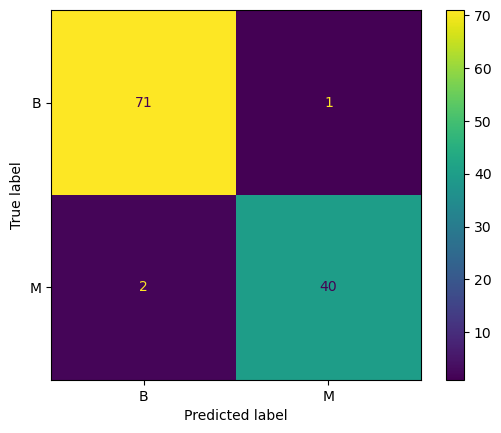

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred,
                                        display_labels=["B", "M"]
                                       )

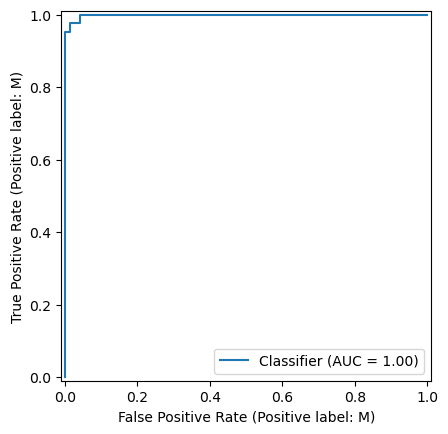

In [94]:
from sklearn.metrics import RocCurveDisplay

y_pred_proba = combined_grid_search1.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_pred_proba, pos_label='M')

<font color = "orange">
The winning model for the breast data was the logistic regression model with data standardization to predict breast cancer diagnosis (benign vs. malignant). Using 5-fold cross-validation with balanced accuracy as the evaluation metric, the model achieved perfect classification on the test set with an AUC of 1.00. The confusion matrix and ROC curve demonstrate excellent performance with hardly any misclassifications on the held-out test data.
</font>